In [ ]:
import torch

if torch.cuda.is_available():
    print(f"CUDA is READY! You are using a: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is still not found. The runtime might not have switched yet.")

CUDA is READY! You are using a: Tesla T4


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading robust dataset...
Successfully loaded 622009 samples.
Training hardware initialized: cuda

Starting Neural Controller Training...
Epoch    0 | MSE Loss: 1.25951529
Epoch  250 | MSE Loss: 0.00367002
Epoch  500 | MSE Loss: 0.00122144
Epoch  750 | MSE Loss: 0.00072548
Epoch 1000 | MSE Loss: 0.00055427
Epoch 1250 | MSE Loss: 0.00047113
Epoch 1500 | MSE Loss: 0.00043817

[SUCCESS] Weights successfully exported to 'foc_mlp_weights.mat'.


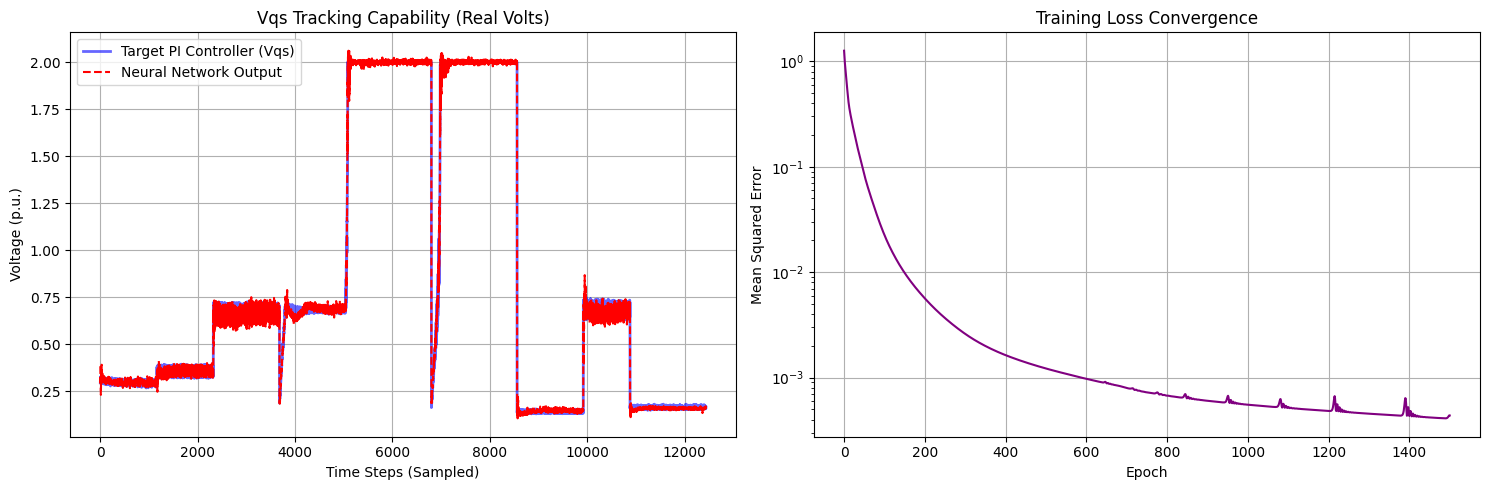

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive

# ─── 1. MOUNT DRIVE & SET PATH ──────────────────────────────────────────
drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Foc_project'
os.chdir(PROJECT_PATH)

print("Loading robust dataset...")
try:
    data = sio.loadmat('foc_dataset_robust.mat')
    X_raw = data['X'].astype(np.float32) # [Spd_ref(RPM), Imag_ref, wr, imr, idseF, iqseF]
    Y_raw = data['Y'].astype(np.float32) # [Vds, Vqs]
    print(f"Successfully loaded {X_raw.shape[0]} samples.")
except FileNotFoundError:
    raise Exception("Dataset not found! Please upload 'foc_dataset_robust.mat' to your FOC_Project folder in Drive.")

# ─── 2. FEATURE ENGINEERING (PER-UNIT ERROR TRACKING) ───────────────────
# The Simulink model operates in per-unit (p.u.). We must match that.
# Base speed is 1500 RPM.
Spd_ref_pu = X_raw[:, 0] / 1500.0

# Replace raw references with tracking ERRORS
# X_raw Column 0 becomes Spd_err = Spd_ref(p.u.) - wr(p.u.)
# X_raw Column 1 becomes Flux_err = Imag_ref - imr
X_raw[:, 0] = Spd_ref_pu - X_raw[:, 2]
X_raw[:, 1] = X_raw[:, 1] - X_raw[:, 3]

# ─── 3. NORMALIZATION ───────────────────────────────────────────────────
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0) + 1e-6
Y_mean, Y_std = Y_raw.mean(axis=0), Y_raw.std(axis=0) + 1e-6

# Setup GPU (CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training hardware initialized: {device}")

X_norm = torch.FloatTensor((X_raw - X_mean) / X_std).to(device)
Y_norm = torch.FloatTensor((Y_raw - Y_mean) / Y_std).to(device)

# ─── 4. NEURAL NETWORK ARCHITECTURE ─────────────────────────────────────
class FOC_Neural_Controller(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 64), nn.LayerNorm(64), nn.ReLU(),
            nn.Linear(64, 64), nn.LayerNorm(64), nn.ReLU(),
            nn.Linear(64, 32), nn.LayerNorm(32), nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(x)

model = FOC_Neural_Controller().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# ─── 5. TRAINING LOOP ───────────────────────────────────────────────────
epochs = 1500
loss_history = []

print("\nStarting Neural Controller Training...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    outputs = model(X_norm)
    loss = criterion(outputs, Y_norm)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if epoch % 250 == 0:
        print(f"Epoch {epoch:4d} | MSE Loss: {loss.item():.8f}")

# ─── 6. EXPORT WEIGHTS & SCALERS ────────────────────────────────────────
weights = {
    'X_mean': X_mean, 'X_std': X_std,
    'Y_mean': Y_mean, 'Y_std': Y_std
}

# Pull parameters from GPU back to CPU to save them
for name, param in model.named_parameters():
    weights[name.replace('.', '_')] = param.detach().cpu().numpy()

sio.savemat('foc_mlp_weights.mat', weights)
print("\n[SUCCESS] Weights successfully exported to 'foc_mlp_weights.mat'.")

# ─── 7. VALIDATION PLOTS ────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    predictions = model(X_norm).cpu().numpy()
    predictions_real = (predictions * Y_std) + Y_mean

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(Y_raw[::50, 1], label='Target PI Controller (Vqs)', color='blue', alpha=0.6, linewidth=2)
plt.plot(predictions_real[::50, 1], '--', label='Neural Network Output', color='red', linewidth=1.5)
plt.title('Vqs Tracking Capability (Real Volts)')
plt.ylabel('Voltage (p.u.)')
plt.xlabel('Time Steps (Sampled)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss_history, color='purple')
plt.yscale('log')
plt.title('Training Loss Convergence')
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.grid(True)
plt.tight_layout()
plt.show()